# Study Case - Serge de Valk

# Table of contents
1. Hypothesis
2. Data selection
3. Construction of spread
4. Construction of macro factors
5. Construction of macro-regimes
6. Defining the strategy
7. Backtest on the hold-out period
8. Discussion of metrics and risk profile of the strategy

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Hypothesis: 
The spread between the 1y1y forward and 5y5y foward in the sovereign Brazilian nominal rates market behaves differently in distinct macro regimes. Given that the shorter term forward is more sensitive to monetary policy and the longer forward to more strutural factors we hypothesize that we can capture movements by designing 4 quadrants (regimes) along those two dimensions (monetary policy and some relevant structural factor - in this case fiscal uncertainty). 

# Data selection:
For this excercise we choose the expected 12-month ahead inflation (IPCA) from the focus survey and the expected primary balance, also from the focus survey. The latter is intended to capture beliefs about the fiscal situation of the central government.

In [354]:
rates = pd.read_excel("interest_rates_sovereign_br.xlsx",
                      header = [10,11],
                      index_col=0) / 100

For the interest rates we will use zero-coupon rates based on an interpolated curved (Nelson-Siegel) from AMBIMA to capture constant maturities.

In [355]:
fwd1y1y = (1+rates[('ETTJ Prefixada','504 dias')])**2 / (1+rates[('ETTJ Prefixada','252 dias')]) - 1

In [356]:
fwd5y5y = ((1+rates[('ETTJ Prefixada','2520 dias')])**10 / (1+rates[('ETTJ Prefixada','1260 dias')])**5)**(1/5) - 1

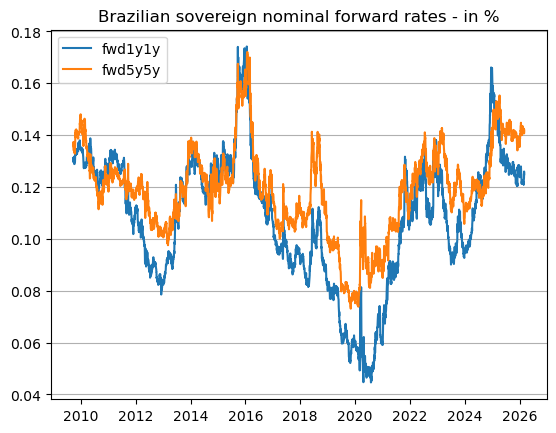

In [357]:
plt.figure()
plt.plot(fwd1y1y,label="fwd1y1y")
plt.plot(fwd5y5y,label="fwd5y5y")
plt.legend()
plt.grid(axis="y")
plt.title("Brazilian sovereign nominal forward rates - in %")
plt.show()

Let us now load the macro data to construct the factors.
1. The first one is the median of the forecasts informed to the central bank through the FOCUS survey.
2. The second one, from the same survey, are the primary balance expectations. I choose primary balance expectations (and not debt dynamics) because they are not a function of interest rates. Otherwise I might be explaining interest rate performance based on interest rate regimes, which is not what I wanted for this excercise.

In [358]:
pi_fcst12m = pd.read_excel("ipca_12m_focus.xlsx",header=[10,11],index_col=0)
pi_fcst12m = pi_fcst12m[('Original','IPCA')] # selecting IPCA

In [359]:
pb_fcst = pd.read_excel("pb_focus.xlsx",header=[11],index_col=0,sheet_name="FISCAL.P")

# Construction of spread

Let us define the spread as the difference between the annualized rates of the two forward instruments such that:

In [360]:
spread = fwd5y5y - fwd1y1y

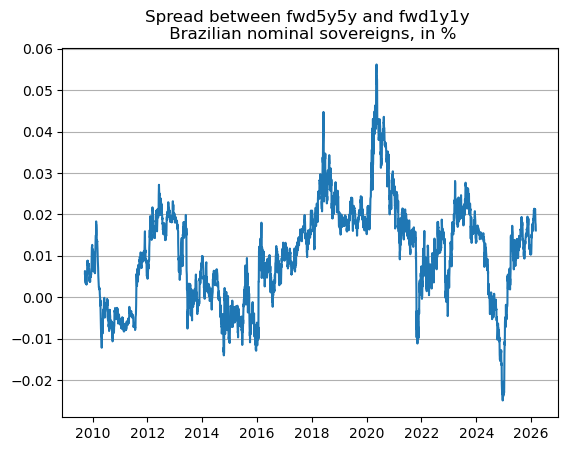

In [361]:
plt.figure()
plt.plot(spread)
plt.title("Spread between fwd5y5y and fwd1y1y \n Brazilian nominal sovereigns, in %")
plt.grid(axis="y")
plt.show()

We now make total return series for each instrument used by simulating a long position in each instrument (hence including carry and MtM). It will however be a proxy since we only have the constant maturity rates to work with.

In [362]:
ttl_ret_1y = (1+rates[('ETTJ Prefixada','252 dias')])**(1/252) * (1+rates[('ETTJ Prefixada','252 dias')])/(1+rates[('ETTJ Prefixada','252 dias')].shift(1))
ttl_ret_1y = ttl_ret_1y.fillna(1).cumprod()
ttl_ret_2y = (1+rates[('ETTJ Prefixada','504 dias')])**(1/252) * (1+rates[('ETTJ Prefixada','504 dias')])**2/(1+rates[('ETTJ Prefixada','504 dias')].shift(1))**2
ttl_ret_2y = ttl_ret_2y.fillna(1).cumprod()
ttl_ret_5y = (1+rates[('ETTJ Prefixada','1260 dias')])**(1/252) * (1+rates[('ETTJ Prefixada','1260 dias')])**5/(1+rates[('ETTJ Prefixada','1260 dias')].shift(1))**5
ttl_ret_5y = ttl_ret_5y.fillna(1).cumprod()
ttl_ret_10y = (1+rates[('ETTJ Prefixada','2520 dias')])**(1/252) * (1+rates[('ETTJ Prefixada','2520 dias')])**10/(1+rates[('ETTJ Prefixada','2520 dias')].shift(1))**10
ttl_ret_10y = ttl_ret_10y.fillna(1).cumprod()

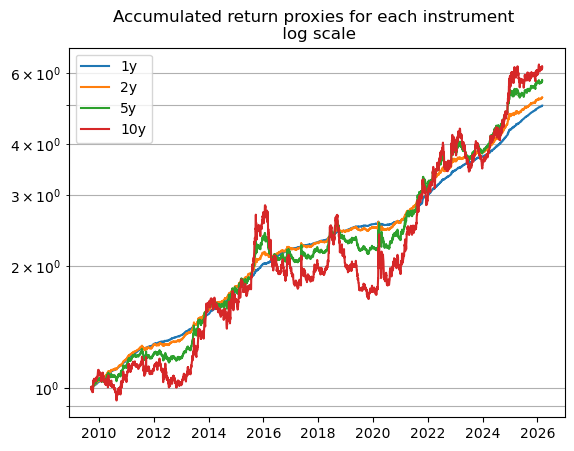

In [363]:
plt.figure()
plt.plot(ttl_ret_1y,label="1y")
plt.plot(ttl_ret_2y,label="2y")
plt.plot(ttl_ret_5y,label="5y")
plt.plot(ttl_ret_10y,label="10y")
plt.yscale('log')
plt.legend()
plt.grid(True, axis='y', which='both')
plt.title("Accumulated return proxies for each instrument \n log scale")
plt.show()

We will now calculate the DV01 for 1bp change in rates for all instruments

In [364]:
dv01_1y = (1 / (1+rates[('ETTJ Prefixada','252 dias')])**1) * (1/(1+rates[('ETTJ Prefixada','252 dias')]))*1e-4
dv01_2y = (1 / (1+rates[('ETTJ Prefixada','504 dias')])**2) * (2/(1+rates[('ETTJ Prefixada','504 dias')]))*1e-4
dv01_5y = (1 / (1+rates[('ETTJ Prefixada','1260 dias')])**5) * (5/(1+rates[('ETTJ Prefixada','1260 dias')]))*1e-4
dv01_10y = (1 / (1+rates[('ETTJ Prefixada','2520 dias')])**10) * (10/(1+rates[('ETTJ Prefixada','2520 dias')]))*1e-4

We will now construct the return of the a long position in 5y5y - 1y1y with a neutralized DV01 exposure. The way it is build implies daily rebalancing to keep the DV01 exposure neutralized. We start by calculatin the long leg then move to the short leg. Finally we combine both into the actual position.

In order to neutralize DV01 we have an equation with 4 unknowns. The easiest way is to set the 3 first unknowns and resolve for the last one:

In [365]:
w1 = -1
w2 = 1
w5 = -1
w10 = -(w1*dv01_1y + w2*dv01_2y + w5*dv01_5y) / dv01_10y

In [366]:
ret_pos = w1*(ttl_ret_1y.pct_change(1)) + w2*ttl_ret_2y.pct_change(1) + w5*ttl_ret_5y.pct_change(1) + w10*ttl_ret_10y.pct_change(1)
ret_pos_1vol = ret_pos/((ret_pos*100).std()*np.sqrt(252))
ret_pos_1vol_acc =  (1+ret_pos_1vol.fillna(0)).cumprod()

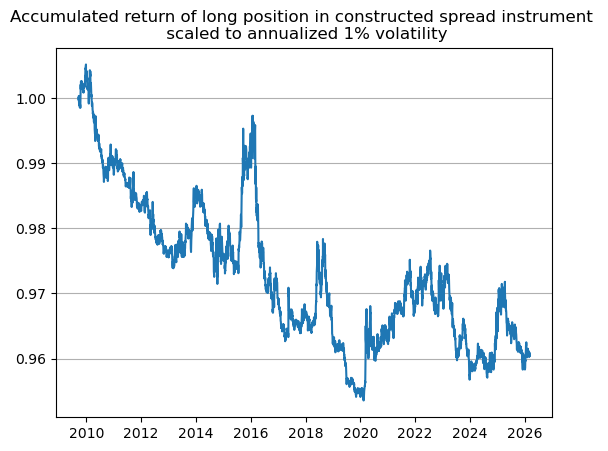

In [367]:
plt.figure()
plt.plot(ret_pos_1vol_acc)
plt.title("Accumulated return of long position in constructed spread instrument \n scaled to annualized 1% volatility")
plt.grid(axis="y")
plt.show()

# Construction of Macro factors:
In this part we will transform the data of the focus survey into macro variables and try to respect as much as possible the idea of working with point-in-time data. Given that we are talking about surveys the good news is that there are no revisions of prior data. The tricky part is when the information was made available. As per the actual rules of the survey, the central bank looks at all informed forecasts on friday afternoon and publishes results on monday at 8:30.

We now define a function to identify the last forecast informed for a given week. This will represent the newest information available during the next week, as the FOCUS survey is only published weekly.

In [368]:
def friday_or_previous_to_next_monday(ts: pd.Series) -> pd.Series:
    """
    From a daily pandas Series with DatetimeIndex:
    - pick each week's Friday value;
    - if Friday is missing, use the most recent previous available day in that week;
    - move the selected date index to the following Monday.
    """
    ts = ts.sort_index().copy()
    ts.index = pd.to_datetime(ts.index)

    # Weekly bins ending on Friday; take last available obs in each bin
    out = ts.resample("W-FRI").last().dropna()

    # Shift index from Friday to next Monday
    out.index = out.index + pd.Timedelta(days=3)

    return out

Let us start with the case of inflation forecasts:

In [369]:
pi_fcs12m_monday = friday_or_previous_to_next_monday(pi_fcst12m)

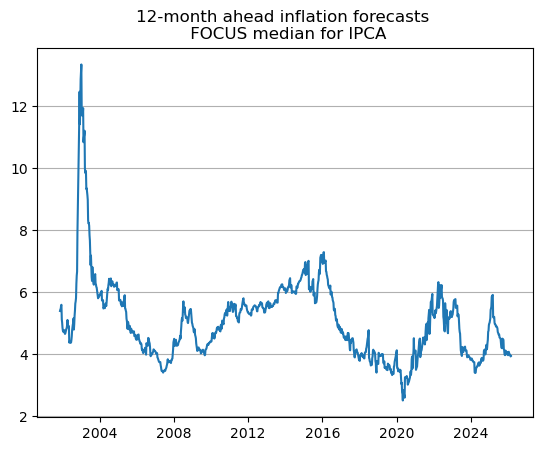

In [370]:
plt.figure()
plt.plot(pi_fcs12m_monday)
plt.title("12-month ahead inflation forecasts \n FOCUS median for IPCA")
plt.grid(axis="y")
plt.show()

Let us now move to the case of primary balance forecasts. We will take 3y ahead forecasts in order to abstract from short term economic conditions. Remenber that we are looking to capture perceptions about the longer term fiscal conditions for this excercise. We will build a rolling weighted series taking the 3y and 4y ahead forecasts (as we come close to year end the 3y ahead will actually be more of a 2y ahead, and we don´t want any possible jumps in the series due to changing years).

In [371]:
def fixed_horizon_from_calendar_forecasts(df: pd.DataFrame, n_years: int) -> pd.Series:
    """
    Construct an exact n-years-ahead 12-month forecast series from calendar-year forecasts.

    Parameters
    ----------
    df : pd.DataFrame
        Index: forecast dates (DatetimeIndex)
        Columns: calendar years (int or str), e.g. 2000, 2001, 2002
        Values: forecast for that calendar year as observed on each date
    n_years : int
        Desired fixed horizon in years.
        Example:
        - n_years=1 -> exact next 12 months
        - n_years=2 -> exact 12 months starting one year from now

    Returns
    -------
    pd.Series
        Fixed-horizon forecast series.
    """
    out = []

    # make sure index is datetime and columns are integer years
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df.columns = pd.Index(df.columns).astype(int)

    for t in df.index:
        start = t + pd.DateOffset(years=n_years - 1)
        end   = t + pd.DateOffset(years=n_years)

        y1 = start.year
        y2 = end.year

        # Jan 1 of the following year after y1
        boundary = pd.Timestamp(y1 + 1, 1, 1)

        total_days = (end - start).total_seconds()
        days_y1 = (min(end, boundary) - start).total_seconds()
        w1 = days_y1 / total_days
        w2 = 1.0 - w1

        f1 = df.at[t, y1] if y1 in df.columns else np.nan
        f2 = df.at[t, y2] if y2 in df.columns else np.nan

        # weighted average, allowing one side to be missing
        if pd.notna(f1) and pd.notna(f2):
            val = w1 * f1 + w2 * f2
        elif pd.notna(f1):
            val = f1
        elif pd.notna(f2):
            val = f2
        else:
            val = np.nan

        out.append(val)

    return pd.Series(out, index=df.index, name=f"fh_{n_years}y")

In [372]:
pb_3y = fixed_horizon_from_calendar_forecasts(pb_fcst, n_years=3)

In [373]:
pb_3y_monday = friday_or_previous_to_next_monday(pb_3y) # same treatment as for inflation

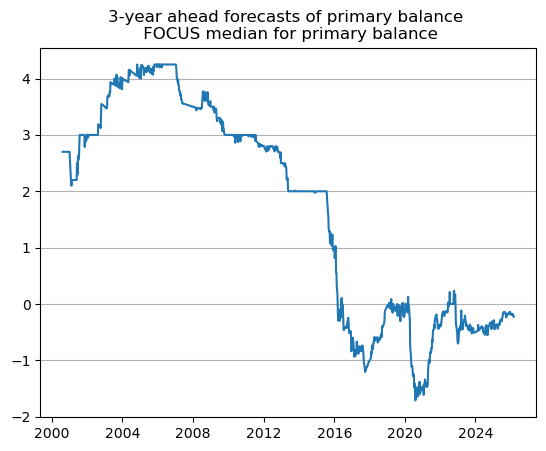

In [374]:
plt.figure()
plt.plot(pb_3y_monday)
plt.title("3-year ahead forecasts of primary balance \n FOCUS median for primary balance")
plt.grid(axis="y")
plt.show()

# Construction of macro-regimes

We will now set out to construct the macro-regimes. I am using 4 week changes in the macro-variables for faster changing regimes.

In [375]:
pb_3y_monday_1mm = pb_3y_monday.diff(4)
pb_3y_monday_1mm.name = "pb"

In [376]:
pi_fcs12m_monday_1mm = pi_fcs12m_monday.diff(4)
pi_fcs12m_monday_1mm.name = "pi"

In [377]:
df_regimes = pd.concat([pb_3y_monday_1mm,pi_fcs12m_monday_1mm],axis=1)
df_regimes = df_regimes.dropna()

The regimes will be classified in 4 quadrants:
1. PB > 0 and PI > 0;
2. PB > 0 and PI <= 0;
3. PB <= 0 and PI > 0;
4. PB <= 0 and PI <= 0;


In [378]:
def classify_regimes(df, col1="pb", col2="pi", threshold=0):
    out = df.copy()

    s1 = out[col1] > threshold
    s2 = out[col2] > threshold

    out["regime"] = np.select(
        [
            s1 & s2,
            s1 & ~s2,
            ~s1 & s2,
            ~s1 & ~s2,
        ],
        [
            f"{col1}+ / {col2}+",
            f"{col1}+ / {col2}-",
            f"{col1}- / {col2}+",
            f"{col1}- / {col2}-",
        ],
        default="unclassified"
    )

    return out

In [379]:
regimes = classify_regimes(df_regimes)

We are now concatenating all variables (regimes and returns of the long position in the spread) into a single dataframe

In [380]:
df_total = pd.concat([regimes["regime"],ret_pos_1vol_acc],
                     axis=1,
                    keys=["regime","ret"])
df_total.loc[:,"regime"] = df_total.loc[:,"regime"].ffill()
df_total = df_total.dropna()
df_total.loc[:,"ret"] = df_total.loc[:,"ret"].pct_change(1).shift(1) # it is important to shift returns here, otherwise we have a temporal mismatch and would use future information!
df_total = df_total.iloc[2:,:]

In order to do a backtest at the end of this excercise we will separate a hold-out set that will only be used when performing the out of sample tests

In [381]:
df_insample = df_total.loc[df_total.index<"2021-1-1",:]
df_holdout = df_total.loc[df_total.index>="2021-1-1",:]

# Defining the strategy

We will now cluster returns per regime and see if their means are significantly different from 0. If their mean is statistically different we define the position based on the signal.

In [382]:
res = smf.ols("ret ~ C(regime) - 1", data=df_insample).fit(cov_type="HC1")
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 08 Mar 2026   Prob (F-statistic):                nan
Time:                        20:34:43   Log-Likelihood:                 16774.
No. Observations:                2831   AIC:                        -3.354e+04
Df Residuals:                    2827   BIC:                        -3.352e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
C(regime)[pb+ / pi+] -3.559e-05 

Conclusions:
1. No regime is statistically significant
2. The signals are not always as expected as for the case of pb+ / pi+. Primary balance expectations improving -> higher returns for 5y5y long and higher inflation expectations -> higher returns for the short 1y1y

For the backtest we will continue with the regime pb+ / pi+ and pb- / pi-, respecting the signs given the above table

# Backtest on the hold-out period

I will now create a return series for the strategy.
we are long when the regime is  pb- / pi- and short when pb+ / pi+. In the remaining two regimes we do not build any position.

In [383]:
df_holdout_strat = df_holdout.copy()
mask = df_holdout_strat["regime"].isin(["pb+ / pi-", "pb- / pi+"])
df_holdout_strat.loc[mask, "ret"] = 0.0 # no position in those states
df_holdout_strat.loc[df_holdout_strat["regime"]=="pb+ / pi+","ret"] = -df_holdout_strat.loc[df_holdout_strat["regime"]=="pb+ / pi+","ret"] # short in this state
df_holdout_strat.loc[df_holdout_strat["regime"]=="pb- / pi-","ret"] = -df_holdout_strat.loc[df_holdout_strat["regime"]=="pb- / pi-","ret"] # short in this state

In [384]:
df_holdout_strat_total_ret = (1+df_holdout_strat["ret"]).cumprod()

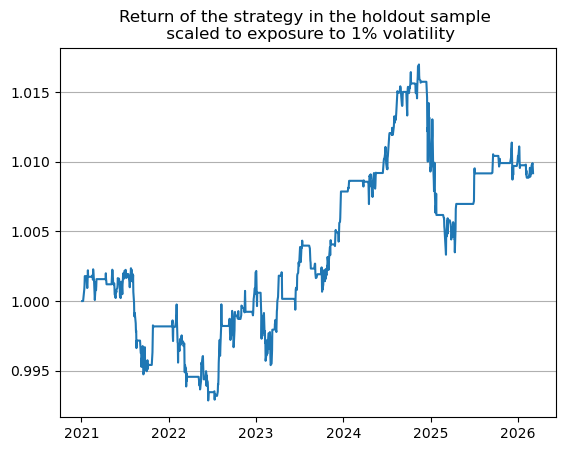

In [385]:
plt.figure()
plt.plot(df_holdout_strat_total_ret)
plt.title("Return of the strategy in the holdout sample \n scaled to exposure to 1% volatility")
plt.grid(axis="y")
plt.show()

# Discussion of metrics and risk profile of the strategy

we now define some of the metrics that we will look at in order to evaluate the strategy. 

In [386]:
def evaluate_strategy(
    tr_index: pd.Series,      # total return index / equity curve (e.g., starts at 1.0)
    freq: int = 252,          # 252 daily, 52 weekly, 12 monthly
    rf: float = 0.0,          # annual risk-free rate in decimal (e.g., 0.10)
) -> dict:
    x = tr_index.dropna().astype(float).sort_index()
    r = x.pct_change().dropna()
    if len(r) == 0:
        raise ValueError("Not enough data points to compute returns.")

    years = len(r) / freq
    cagr = (x.iloc[-1] / x.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan

    vol = r.std(ddof=1) * np.sqrt(freq)

    rf_per_period = (1 + rf) ** (1 / freq) - 1
    ex = r - rf_per_period
    sharpe = (ex.mean() / ex.std(ddof=1)) * np.sqrt(freq) if ex.std(ddof=1) > 0 else np.nan

    downside_std = r[r < 0].std(ddof=1)
    sortino = ((r.mean() - rf_per_period) / downside_std) * np.sqrt(freq) if (r < 0).sum() > 1 and downside_std > 0 else np.nan

    running_max = x.cummax()
    dd = x / running_max - 1.0
    mdd = dd.min()

    return {
        "start": x.index[0],
        "end": x.index[-1],
        "n_periods": len(r),
        "CAGR": cagr,
        "AnnVol": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "MaxDrawdown": mdd,
    }

In [387]:
stats = evaluate_strategy(df_holdout_strat_total_ret, freq=252, rf=0.0)
pd.Series(stats)

start          2021-01-04 00:00:00
end            2026-03-04 00:00:00
n_periods                     1296
CAGR                      0.001779
AnnVol                    0.006945
Sharpe                    0.259453
Sortino                   0.244085
MaxDrawdown              -0.013438
dtype: object

Sharpe is quite low and might not survive transaction costs. The Max Drawdown shows a 1.3% drop from high, twice the annualized volatility.